# WarehouseSort — Starter Notebook

This notebook walks through the **state IL pipeline** (main track) end-to-end on the easy level:
install → look at the env → download demos → train a state Diffusion Policy → evaluate.

The policy reads the **privileged low-dim state vector** (proprioception + parcel poses & tag
colors + bin positions). The provided state Diffusion Policy is your starting point — your job is to improve it. *(An optional harder image/rgb track exists too — see
the README.)*

**Requirements:** a CUDA GPU. In Google Colab: *Runtime → Change runtime type → T4 GPU*.

References:
- [ManiSkill 3](https://maniskill.readthedocs.io/en/latest/) — GPU-accelerated robot simulation
- [Diffusion Policy](https://diffusion-policy.cs.columbia.edu) — Chi et al. 2023

### What a solved episode looks like

The scripted policy (used only to generate the demos) sorting parcels into the
color-matched bins — left panel is the scene view, right is the policy's camera:

![easy demo](https://github.com/marso-robotics/berlin-marso-hackathon/raw/main/media/easy_demo.gif)

*(medium = 4 parcels, hard = 6 parcels with bins that may swap sides — see the README.)*

## 1. Install

In [16]:
# Install ManiSkill and dependencies (takes ~2 min on Colab)
!pip install mani-skill==3.0.1 diffusers==0.38.0 gymnasium torch torchvision hydra-core -q

# Clone the repo (skip if already in the repo directory)
import os
if not os.path.exists('warehouse_sort'):
    !git clone https://github.com/marso-robotics/berlin-marso-hackathon.git
    %cd berlin-marso-hackathon

# Install the package
!pip install -e . -q

# Colab headless rendering (offscreen Vulkan)
import os
os.environ['DISPLAY'] = ''
os.environ['PYOPENGL_PLATFORM'] = 'egl'

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for warehouse_sort (pyproject.toml) ... done


## 2. Look at the environment

**Easy level**: 2 parcels (1 red-tagged, 1 blue-tagged), 2 color-coded bins, fixed positions.
The observation is the **state vector**: robot proprioception + parcel poses & tag colors + bin
positions & colors. Its size depends on the parcel count, so a state policy is **level-specific**.

In [17]:
import gymnasium as gym
import torch
import warehouse_sort  # registers WarehouseSort-v1

env = gym.make(
    'WarehouseSort-v1', num_envs=1, obs_mode='state',
    control_mode='pd_ee_delta_pos', sim_backend='gpu', render_mode='rgb_array',
    difficulty='easy', num_parcels=2, fixed_poses=True,
)

obs, _ = env.reset(seed=42)
print('state obs shape:', tuple(obs.shape))            # (1, 54) for easy (2 parcels)
print('action space   :', env.unwrapped.single_action_space)     # Box(-1,1,(4,))
print()
print('The state vector includes parcel poses, tag colors, and bin positions —')
print('its length grows with the parcel count, so train one model per level.')

state obs shape: (1, 54)
action space   : Box(-1.0, 1.0, (4,), float32)

The state vector includes parcel poses, tag colors, and bin positions —
its length grows with the parcel count, so train one model per level.


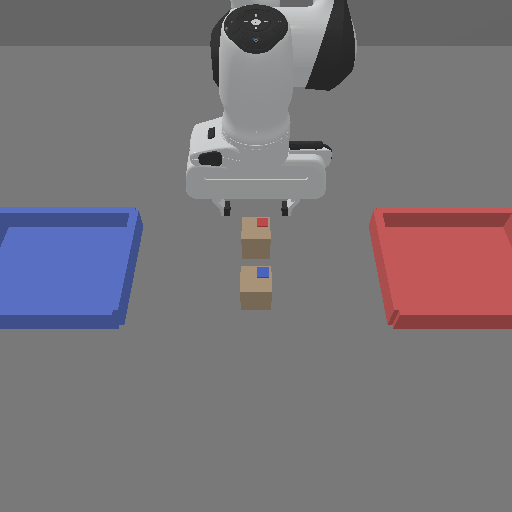

In [18]:
# Render the scene
from IPython.display import Image as IPImage
import PIL.Image, io

frame = env.render()                    # (1, H, W, 3) uint8
img = PIL.Image.fromarray(frame[0].cpu().numpy())
buf = io.BytesIO()
img.save(buf, format='PNG')
IPImage(buf.getvalue())

In [19]:
# Run the scripted waypoint policy to verify the env works (it generates the demos;
# it reads privileged sim state to control the arm, so it is NOT a submittable policy).
import sys
sys.path.insert(0, '.')
from examples.scripted_policy import scripted_episode

env.close()
env = gym.make('WarehouseSort-v1', num_envs=1, obs_mode='state',
               control_mode='pd_ee_delta_pos', sim_backend='gpu',
               difficulty='easy', num_parcels=2, fixed_poses=True, max_episode_steps=200)
history = scripted_episode(env, max_steps=200, seed=42)
final_info = history[-1][-1]
print(f"Sorted: {final_info['success_count'].item():.0f} / 2")
env.close()

  step   0  phase=OPEN      parcel=0  tcp=[-0.    0.    0.17]  sorted=0.0
  step  20  phase=GRASP     parcel=0  tcp=[-0.061 -0.     0.062]  sorted=0.0
  step  40  phase=CARRY     parcel=0  tcp=[-0.019  0.085  0.286]  sorted=0.0
  step  60  phase=ABOVE     parcel=1  tcp=[-0.01   0.353  0.099]  sorted=1.0
  step  80  phase=GRASP     parcel=1  tcp=[ 0.05  -0.     0.059]  sorted=1.0
  step 100  phase=CARRY     parcel=1  tcp=[ 0.014 -0.059  0.3  ]  sorted=1.0
Sorted: 2 / 2


## 3. Demonstrations (provided — Kaggle competition data)

The demos (**200 episodes per level**, state for the main track) are the competition data:
[the data tab](https://www.kaggle.com/competitions/marso-hack-berlin-2026-robot-parcel-sorting-challenge/data). You don't need to record any.

- **On Kaggle** (notebook attached to the competition): the data is already mounted under
  `/kaggle/input/` — nothing to set up; the cell below finds it.
- **On Colab / local**: the cell downloads it with `kagglehub`, which needs your Kaggle API
  credentials (one-time). First **join the competition** (Rules → *I Understand and Accept*),
  then get a token: on kaggle.com click your **avatar → Settings → API → Create New API Token**.
  (Ensure you use the legacy method to download `kaggle.json` containing your `username` and `key`). Then set them in the cell —
  the auth lines are at the top, just uncomment and paste your values.

Either way the cell stages the files under `il/demos/<level>/` so the training commands below
work unchanged.

> ⚠️ The demos come from a scripted policy. Using it to collect *data* is fine, but submitting a
> scripted / hard-coded controller (or any policy that reads privileged env state) is
> **disqualified** — your submitted policy must act from the observation.

In [20]:
# The demos (200 episodes per level) are the Kaggle COMPETITION data.
COMPETITION = 'marso-hack-berlin-2026-robot-parcel-sorting-challenge'

import os, glob, shutil, tarfile

# --- Colab / local auth (NOT needed on Kaggle) -------------------------------------------
# After joining the competition, get a token from kaggle.com -> Settings -> API ->
# 'Create New API Token' (downloads kaggle.json), then uncomment and paste its values:
os.environ['KAGGLE_USERNAME'] = 'unrealdrip'
os.environ['KAGGLE_KEY']      = '412081ee9034f8cc6665fe2560ecb92b'      # the 'key' field in kaggle.json
# (Alternatively run  `import kagglehub; kagglehub.login()`  for an interactive prompt.)
# -----------------------------------------------------------------------------------------

# 1) locate the data: a Kaggle-mounted input, else download via kagglehub
src = next((p for p in glob.glob('/kaggle/input/*')
           if glob.glob(os.path.join(p, '**/trajectory.*.pd_ee_delta_pos.physx_cuda.h5'), recursive=True)
           or glob.glob(os.path.join(p, '**/*.tar.gz'), recursive=True)), None)
if src is None:
    import kagglehub
    src = kagglehub.competition_download(COMPETITION)
print('data at:', src)

# 2) stage into il/demos/<level>/  (handles a tarball OR an easy/medium/hard folder layout)
os.makedirs('il/demos', exist_ok=True)
tars = glob.glob(os.path.join(src, '**/*.tar.gz'), recursive=True)
if tars:
    for t in tars:
        with tarfile.open(t) as tf: tf.extractall('il/demos')
else:
    for h5 in glob.glob(os.path.join(src, '**/trajectory.*.pd_ee_delta_pos.physx_cuda.h5'), recursive=True):
        lvl = os.path.basename(os.path.dirname(h5))
        os.makedirs(f'il/demos/{lvl}', exist_ok=True)
        for f in glob.glob(h5[:-2] + '*'):   # the .h5 and its .json
            shutil.copy(f, f'il/demos/{lvl}/{os.path.basename(f)}')
print('staged levels:', sorted(os.path.basename(os.path.dirname(x))
                               for x in glob.glob('il/demos/*/trajectory.*.pd_ee_delta_pos.physx_cuda.h5')))

data at: /root/.cache/kagglehub/competitions/marso-hack-berlin-2026-robot-parcel-sorting-challenge
staged levels: ['easy', 'easy', 'hard', 'hard', 'medium', 'medium']


In [21]:
# Check the state demos are present
import glob
for f in sorted(glob.glob('il/demos/easy/*.state*.h5')):
    print(f)

il/demos/easy/trajectory.state.pd_ee_delta_pos.physx_cuda.h5


### 📈 Watch training live with TensorBoard

Run the two lines below **before** the training cell. `%tensorboard` starts a background
server and embeds a dashboard that **auto-refreshes as training writes metrics** (loss,
eval sort accuracy), so you can keep watching while the training cell runs.


In [ ]:
%load_ext tensorboard
%tensorboard --logdir il/baselines/diffusion_policy/runs

## 4. Train the state Diffusion Policy

[Diffusion Policy](https://diffusion-policy.cs.columbia.edu) (Chi et al. 2023): a plain MLP
behavior cloner fails due to compounding error; DP's action chunking fixes it.

This uses a short run (`total_iters=10000`) to verify the pipeline. **For real training scale up
to `total_iters=30000`+** (~20–40 min on a T4 for easy; more for medium/hard).

> ⚠️ **One model per level.** The state vector's size depends on the parcel count, so a checkpoint
> is specific to its level — train (and submit) a separate one for easy, medium, and hard.

In [ ]:
# Quick training run (verify pipeline; not fully converged)
!python il/train.py method=dp demo_dir=easy \
    flags.total_iters=10000 \
    flags.eval_freq=5000 \
    flags.exp_name=warehouse_state_dp_starter \
    +flags.lr=1e-4 # Example: changing the learning rate

[il/train] method=dp
[il/train] cwd=/content/berlin-marso-hackathon/il/baselines/diffusion_policy
[il/train] /usr/bin/python3 train.py --demo-path /content/berlin-marso-hackathon/il/demos/easy/trajectory.state.pd_ee_delta_pos.physx_cuda.h5 --env-id WarehouseSort-v1 --control-mode pd_ee_delta_pos --sim-backend gpu --max-episode-steps 200 --total-iters 10000 --batch-size 256 --obs-horizon 2 --act-horizon 8 --pred-horizon 16 --num-eval-envs 8 --num-eval-episodes 16 --eval-freq 5000 --log-freq 1000 --save-freq 10000 --capture-video --exp-name warehouse_state_dp_starter --lr 0.0001
2026-06-21 05:22:21.071839: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Traceback (most recent call last):
  File "/usr/lib/python3.12/subprocess.py", line 1264, in wai

In [ ]:
# For real training (uncomment and run)
# !python il/train.py method=dp demo_dir=easy \
#     flags.total_iters=30000 \
#     flags.eval_freq=5000 \
#     flags.exp_name=warehouse_state_dp_easy

In [ ]:
import textwrap

path = '/content/berlin-marso-hackathon/warehouse_sort/il_policy.py'
text = open(path).read()

OLD = textwrap.dedent('''
def load_dp(checkpoint, sample_obs, action_space, device,
            obs_horizon=2, pred_horizon=16, diffusion_step_embed_dim=64,
            unet_dims=(64, 128, 256), n_groups=8, num_diffusion_iters=100,
            num_inference_steps=16):
    """Load a state Diffusion Policy checkpoint (uses EMA weights)."""
    _add_baseline_path("diffusion_policy")
    from diffusion_policy.conditional_unet1d import ConditionalUnet1D
    from diffusers.schedulers.scheduling_ddpm import DDPMScheduler

    state = sample_obs["state"] if isinstance(sample_obs, dict) else sample_obs
    obs_dim = state.shape[1]
    act_dim = action_space.shape[0]
    net = ConditionalUnet1D(
        input_dim=act_dim, global_cond_dim=obs_horizon * obs_dim,
        diffusion_step_embed_dim=diffusion_step_embed_dim,
        down_dims=list(unet_dims), n_groups=n_groups,
    )
    ckpt = torch.load(checkpoint, map_location=device, weights_only=False)
    sd = ckpt.get("ema_agent", ckpt.get("agent"))
    net_sd = {k.replace("noise_pred_net.", "", 1): v for k, v in sd.items()
              if k.startswith("noise_pred_net.")}
    net.load_state_dict(net_sd)
    scheduler = DDPMScheduler(num_train_timesteps=num_diffusion_iters,
                              beta_schedule="squaredcos_cap_v2", clip_sample=True,
                              prediction_type="epsilon")
    return _DPPolicy(net, scheduler, obs_horizon, pred_horizon, act_dim, device,
                     num_inference_steps=num_inference_steps)
''').strip()

NEW = textwrap.dedent('''
def load_dp(checkpoint, sample_obs, action_space, device,
            obs_horizon=2, pred_horizon=16, diffusion_step_embed_dim=64,
            unet_dims=(64, 128, 256), n_groups=8, num_diffusion_iters=100,
            num_inference_steps=16):
    """Load a state Diffusion Policy checkpoint (uses EMA weights)."""
    _add_baseline_path("diffusion_policy")
    from diffusion_policy.conditional_unet1d import ConditionalUnet1D
    from diffusers.schedulers.scheduling_ddpm import DDPMScheduler

    ckpt = torch.load(checkpoint, map_location=device, weights_only=False)
    cfg = ckpt.get("config") or {}
    obs_horizon = int(cfg.get("obs_horizon", obs_horizon))
    pred_horizon = int(cfg.get("pred_horizon", pred_horizon))
    num_inference_steps = int(cfg.get("num_inference_steps", num_inference_steps))

    state = sample_obs["state"] if isinstance(sample_obs, dict) else sample_obs
    obs_dim = state.shape[-1]
    act_dim = action_space.shape[0]
    print(f"[load_dp] obs_dim={obs_dim} obs_horizon={obs_horizon} "
          f"global_cond={obs_horizon * obs_dim}", flush=True)

    net = ConditionalUnet1D(
        input_dim=act_dim, global_cond_dim=obs_horizon * obs_dim,
        diffusion_step_embed_dim=diffusion_step_embed_dim,
        down_dims=list(unet_dims), n_groups=n_groups,
    )
    sd = ckpt.get("ema_agent", ckpt.get("agent"))
    net_sd = {k.replace("noise_pred_net.", "", 1): v for k, v in sd.items()
              if k.startswith("noise_pred_net.")}
    net.load_state_dict(net_sd)
    scheduler = DDPMScheduler(num_train_timesteps=num_diffusion_iters,
                              beta_schedule="squaredcos_cap_v2", clip_sample=True,
                              prediction_type="epsilon")
    return _DPPolicy(net, scheduler, obs_horizon, pred_horizon, act_dim, device,
                     num_inference_steps=num_inference_steps)
''').strip()

if OLD not in text:
    raise RuntimeError("Patch failed — file already patched or repo version changed")
open(path, 'w').write(text.replace(OLD, NEW))
print("Patched load_dp to read obs_horizon from checkpoint config")

Patched load_dp to read obs_horizon from checkpoint config


## 5. Evaluate the checkpoint

In [ ]:
import glob, os

# Adjust these to MATCH exactly what you used in your training command
OBS_HORIZON = 10
ACT_HORIZON = 4
PRED_HORIZON = 16

# Find the checkpoint file
ckpts = ['/content/20000.pt']

if not ckpts:
    print('No checkpoint files found. Please ensure training has completed.')
else:
    print(f'Found {len(ckpts)} checkpoint(s). Evaluating with Obs:{OBS_HORIZON}, Act:{ACT_HORIZON}, Pred:{PRED_HORIZON}')
    for ckpt_file in ckpts:
        print(f'\n--- Evaluating checkpoint: {ckpt_file} ---')
        !python eval.py difficulty=easy difficulty.num_parcels=2 \
            policy=warehouse_sort.il_policy:load_dp \
            checkpoint={ckpt_file} \
            +obs_horizon={OBS_HORIZON} \
            +act_horizon={ACT_HORIZON} \
            +pred_horizon={PRED_HORIZON} \
            eval_config=conf/eval/default.yaml
        print(f'--- Finished evaluating: {ckpt_file} ---')

Found 1 checkpoint(s). Evaluating with Obs:10, Act:4, Pred:16

--- Evaluating checkpoint: /content/20000.pt ---
/usr/local/lib/python3.12/dist-packages/sapien/_vulkan_tricks.py:42: UserWarning: Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.
  warn("Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.")
[eval] git=2cee4d91d3fad1df98b678e17322e1b2fe24f911
----------------------------------------------------------------------
difficulty:
  name: easy
  num_parcels: 2
  fixed_poses: true
randomization:
  parcel_pose:
    xy_jitter:
    - 0.0
    - 0.0
    yaw_jitter:
    - 0.0
    - 0.0
  bin_position:
    side_swap_prob: 0.0
    xy_jitter:
    - 0.0
    - 0.0
seed: 0
num_envs: 8
device: cuda
control_mode: pd_ee_delta_pos
max_episode_steps: 200
obs_mode: state
camera:
  width: 128
  height: 128
obs_camera: scene
checkpoint: /content/20000.pt
eval_config: conf/eval/default.yaml
policy: warehouse_sort.il_policy:load_dp
obs_horizon: 10
act_horizon: 4


In [37]:
import torch

ckpt_path = '/content/24000.pt'
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

print("=== checkpoint keys ===")
print(list(ckpt.keys()))
print()

print("=== saved config (use these for eval) ===")
print(ckpt.get('config'))
print()

# Read architecture from weights
sd = ckpt.get('ema_agent', ckpt.get('agent', {}))
net_sd = {k.replace('noise_pred_net.', '', 1): v for k, v in sd.items()
          if k.startswith('noise_pred_net.')}

dsed = net_sd['diffusion_step_encoder.1.weight'].shape[1]
cond_dim = net_sd['down_modules.0.0.cond_encoder.1.weight'].shape[1]
global_cond = cond_dim - dsed

print(f"global_cond_dim = {global_cond}  (checkpoint expects this)")
print(f"obs_horizon from config = {ckpt['config']['obs_horizon']}")
print()

# Match difficulty by parcel count
# obs_dim = 26 + P*7 + P*2 + 6 + 4
for name, P in [('easy', 2), ('medium', 4), ('hard', 6)]:
    obs_dim = 26 + P * 7 + P * 2 + 6 + 4
    implied_h = global_cond // obs_dim if global_cond % obs_dim == 0 else None
    match = '✓ MATCH' if implied_h == ckpt['config']['obs_horizon'] else ''
    print(f"{name:6s}  P={P}  obs_dim={obs_dim}  implied obs_horizon={implied_h}  {match}")

=== checkpoint keys ===
['agent', 'ema_agent', 'optimizer', 'lr_scheduler', 'ema_state', 'iteration', 'config']

=== saved config (use these for eval) ===
{'obs_horizon': 10, 'act_horizon': 4, 'pred_horizon': 16, 'open_loop': True, 'num_inference_steps': 16}

global_cond_dim = 720  (checkpoint expects this)
obs_horizon from config = 10

easy    P=2  obs_dim=54  implied obs_horizon=None  
medium  P=4  obs_dim=72  implied obs_horizon=10  ✓ MATCH
hard    P=6  obs_dim=90  implied obs_horizon=8  


In [ ]:
import warehouse_sort.il_policy as ilp

_orig_load_dp = ilp.load_dp

def load_dp_patched(checkpoint, sample_obs, action_space, device, **kwargs):
    kwargs.setdefault('obs_horizon', 4)
    kwargs.setdefault('act_horizon', 4)
    kwargs.setdefault('pred_horizon', 16)
    return _orig_load_dp(checkpoint, sample_obs, action_space, device, **kwargs)

ilp.load_dp = load_dp_patched
print("Patched load_dp → obs_horizon=4, act_horizon=4")

Patched load_dp → obs_horizon=4, act_horizon=4


**Watch the rollout.** `eval.py` prints the metrics above and saves a rollout video (render + policy-camera views). Display it below — with the untrained template the arm mostly flails, which is exactly the gap you're closing.

In [38]:
# Display the eval rollout video (eval.py saves one under outputs/<date>/<time>/videos/)
import glob, os
from IPython.display import Video, display
vids = sorted(glob.glob('outputs/**/videos/*.mp4', recursive=True), key=os.path.getmtime)
if vids:
    print('eval rollout:', vids[-1])
    display(Video(vids[-1], embed=True, width=640))
else:
    print('No eval video found — run the eval cell above first.')

eval rollout: outputs/2026-06-21/11-37-36/videos/0.mp4


## 6. Scaling to medium and hard

Medium (4 parcels) and hard (6 parcels) use the **same pipeline** — but because the state vector
is parcel-count-specific you must **train a separate checkpoint per level** (you can't reuse the
easy model). Just change `demo_dir` and `difficulty`:

```bash
python il/train.py method=dp demo_dir=medium flags.total_iters=50000 flags.exp_name=warehouse_state_dp_medium
python eval.py difficulty=medium policy=warehouse_sort.il_policy:load_dp \
    checkpoint=il/baselines/diffusion_policy/runs/warehouse_state_dp_medium/checkpoints/best_eval_sort_accuracy.pt \
    eval_config=conf/eval/default.yaml

python il/train.py method=dp demo_dir=hard flags.total_iters=60000 flags.exp_name=warehouse_state_dp_hard
python eval.py difficulty=hard policy=warehouse_sort.il_policy:load_dp \
    checkpoint=il/baselines/diffusion_policy/runs/warehouse_state_dp_hard/checkpoints/best_eval_sort_accuracy.pt \
    eval_config=conf/eval/default.yaml
```

Tip: a longer `flags.pred_horizon` (e.g. 32) can help on the longer-horizon levels.

## 7. Optional — image-based track (harder)

Want a harder, more realistic challenge? Try the **RGB** track: the policy sees only a
scene-camera image + proprioception — **no privileged state**. The competition data already
includes the rgb demos (staged in §3), and because the image has a fixed shape, **one rgb
checkpoint can run on all levels**. It's a **template that does not yet solve the task** —
getting an image policy to sort is an open problem.

```bash
# train the RGB Diffusion Policy (ResNet18 + SpatialSoftmax encoder)
python il/train.py method=dp_rgb demo_dir=easy flags.exp_name=warehouse_rgb_dp

# evaluate it (obs_mode=rgb, load_dp_rgb)
python eval.py difficulty=easy obs_mode=rgb \
    policy=warehouse_sort.il_policy:load_dp_rgb \
    checkpoint=il/baselines/diffusion_policy/runs/warehouse_rgb_dp/checkpoints/best_eval_sort_accuracy.pt \
    eval_config=conf/eval/default.yaml
```

## 8. Next steps — how to submit

You've trained and evaluated a policy. From here:

1. **Push to medium and hard** (§6) — they carry the most weight (medium 0.3, hard 0.5).
2. **Or bring your own approach** — any policy that implements the
   `act(obs, deterministic=True)` contract works (RL, scripted, transformer, ...).
3. **Package your entry** — you submit a **GitHub repo** containing your policy
   entrypoint, your checkpoint(s), and a `submission.yaml` declaring the levels +
   checkpoint for each.

**Read [SUBMISSION.md](https://github.com/marso-robotics/berlin-marso-hackathon/blob/main/SUBMISSION.md)**
for the full guide: how the code ties together, the policy contract (with a minimal
example), how to declare what gets scored, and exactly how to submit.

> If you're on Colab, `SUBMISSION.md` and `submission.example.yaml` are also in the
> repo you cloned in step 1 — open them from the file browser on the left.


**What you submit (3 things):** your **codebase** (this repo, forked) · a **`submission.yaml`** (per-level checkpoint) · your **checkpoint(s)** plus the **policy entrypoint** `module:function` that loads them into `act(obs)`.

### Ideas to improve the baseline

- **Train longer / more data**: raise `flags.total_iters`; record more demos with `il/gen_demos.py`.
- **Horizons**: `flags.pred_horizon`, `flags.act_horizon`, `flags.obs_horizon`.
- **Eval denoising steps**: `num_inference_steps` in `load_dp` (more = better, slower).
- **Capacity**: `unet_dims`, `diffusion_step_embed_dim`; **optimisation**: `flags.batch_size`, LR.
- **Generalise** to the held-out wider positions / bin-swaps (hard is weighted 0.5).

> ⚠️ If you change an architecture/horizon hyperparameter for training, pass the **same** value to your policy loader (`load_dp(...)`) or the checkpoint won't load.